In [330]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold,SelectKBest,SelectPercentile
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings(action='ignore')

In [331]:
datasets = ['tips', 'diamonds', 'fmri']
dfs = [sns.load_dataset(name) for name in datasets]

# Data Preprocessing

In [332]:
def compute_dtype(df):
    return df.dtypes
def compute_nunique(df):
    return df.nunique()
def compute_null_percentage(df):
    return (df.isnull().mean() * 100)

In [333]:
def numerical_data(df):
    return df.select_dtypes(include=['number']).columns

In [334]:
def categorical_data(df, threshold = 5):
    return [feature for feature in df.columns
          if df[feature].nunique()<=threshold ]

In [335]:
def str_data(df):
    return df.select_dtypes(include=['object']).columns

In [336]:
#Used for categorical variables.
def fill_na_mode(df):
    str_col=str_data(df)
    for feature in str_col:
        mode=df[feature].mode()[0]
        df[feature].fillna(mode, inplace=True)
    return df

In [337]:
#Better for skewed distributions or data with outliers.
def fill_na_median(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        median=df[feature].median()
        df[feature].fillna(median, inplace=True)
    return df

In [338]:
#Suitable for symmetric (normal) distributions without outliers.
def fill_na_mean(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        mean=df[feature].mean()
        df[feature].fillna(mean, inplace=True)
    return df

In [339]:
def is_null(df):
    return df.isnull().sum()

In [340]:
def drop_null_all_row(df):
    df.dropna(how='any',inplace=True)
    return df

In [341]:
def drop_null_row(df,columns):
    df.dropna(subset=[columns],inplace=True)
    return df

In [342]:
def is_duplicate(df):
    return df.duplicated().sum()

In [343]:
def remove_duplicate(df):
    df.drop_duplicates(inplace = True) 

# EDA

In [344]:
def plot_hist(df,x,xlabel,title,palette):
    plt.figure(figsize=(12, 2))
    sns.histplot(df[x], palette=palette)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Freq')
    plt.show()

In [345]:
def plot_bar(df,x,y,title,palette):
    plt.figure(figsize=(12, 2))
    sns.barplot(x=x,y=y,data=df,palette=palette)
    plt.title(title)
    plt.show()

In [346]:
def plot_pie(df,x,xlabel,ylabel,title,palette):
    plt.figure(figsize=(12, 2))
    plt.pie(df[x].unique(),labels=df[x].unique(),autopct="%1.1f%%", palette=palette)
    plt.title(title)
    plt.show()

In [347]:
def plot_box(df,x,palette):
    plt.figure(figsize=(12, 2))
    sns.boxplot(x=x, data=df, palette=palette)
    plt.title('Box Plot')
    plt.show()

In [348]:
def plot_scatter(x,y,z,xlabel,ylabel,palette):
    plt.figure(figsize=(12, 2))
    sns.scatterplot(x=x, y=y,hue=z, palette=palette)
    plt.title('Scatter Plot')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Feature Engineering 

## 1.Numerical Feature Engineering 

### 1.1 Scalling

#### 1.1.1 Normalization 

##### Min-Max Scaling

In [349]:
def mm_scaler(df):
    numerical_col=numerical_data(df)
    scaler=MinMaxScaler()
    for feature in numerical_col:
        df[feature]=scaler.fit_transform(df[[feature]])
    return df 

##### Log normalization

In [350]:
def log_normal(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        negative_feature = df[feature] < 0
        df[feature] = np.log1p(np.abs(df[feature]))
        df[feature]=np.where(negative_feature,-df[feature],df[feature])
    return df 

#### 1.1.2 Standardization 

##### Z-Score Scaling

In [351]:
def z_scaler(df):
    numerical_col=numerical_data(df)
    scaler=StandardScaler()
    for feature in numerical_col:
        df[feature]=scaler.fit_transform(df[[feature]])
    return df 

### 1.2 Discretization

In [352]:
def bin_numerical_features(df, bins=10):
    numerical_col = numerical_data(df)
    for feature in numerical_col:
        df[feature + '_binned'] = pd.cut(df[feature], bins=bins, labels=False)
    return df

### 1.3 Descriptive Feature

#### 1.3.1 Skewness

In [353]:
#Positive Skew-->(mean > median)
#Negative Skew-->(mean < median)
#Zero Skewness-->Symmetrical distribution (mean ≈ median) Normal distribution 

In [354]:
#Log or Square Root Transformation (Best for Right Skew)
#Squaring (Best for Negative Skew)
def skewness(df):
    numerical_col=numerical_data(df)
    df_skew=df[numerical_col].apply(lambda x:x.skew())
    df_skew = df_skew.sort_values(ascending=False)
    df_skew=df_skew.reset_index()
    df_skew.columns = ['Feature', 'SkewFactor']
    return df_skew

#### 1.2.3 Quantile and Precentiles

In [355]:
def quartiles(df):
    numerical_cols = numerical_data(df)
    return df[numerical_cols].quantile([0.25, 0.5, 0.75]).T

#### 1.3 Feature Transformation

In [356]:
def sqrt_transform(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        df[feature] = np.sqrt(df[feature])
    return df 

In [357]:
def sq_transform(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        df[feature] = np.square(df[feature])
    return df 

In [358]:
def correlation(df,target):
    numerical_col=numerical_data(df)
    correlation_matrix = df[numerical_col].corr()
    correlation_target=correlation_matrix[target].sort_values(ascending=False)
    correlation_target=correlation_target.reset_index()
    correlation_target.columns=['feature','corr factor']
    return correlation_target

## 2.Categorical Feature Engineering

#### One-Hot Encoding.

In [359]:
def one_hot_encoding(df):
    str_col=categorical_data(df)
    df=pd.get_dummies(df,columns=str_col)
    return df

#### Label Encoding

In [360]:
def label_encoding(df):
    str_col=categorical_data(df)
    encoder=LabelEncoder()
    for feature in str_col:
        df[feature]=encoder.fit_transform(df[[feature]])
    return df

#### Ordinal Encoding

In [361]:
def ordinal_encode(df,str_col):
    encoder = OrdinalEncoder()
    df[str_col] = encoder.fit_transform(df[[str_col]])
    return df

# Feature Splitting

In [362]:
def split_test_train(x,y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    return x_train, x_test, y_train, y_test

# Feature Selection

## 1.Variance Threshold Selection

In [363]:
#removes features with low variance
def var_th(x,th=0.05):
    feature_names = list(x.columns)
    selector = VarianceThreshold(threshold=th) 
    feature_select = selector.fit_transform(x)
    selected_col=selector.get_support(indices=True)
    x_selected_features = [feature_names[idx] for idx in selected_col]
    return x_selected_features,selector.variances_

In [364]:
def result_var_th(x,th):
    feature_selected,var=var_th(x,th=0.05)
    print('Feature_Selected is ',feature_selected)
    df={'feature':feature_selected,'feature_variance':var}
    plot_bar(df=df,x='feature_variance',y='feature',title='variance of features',palette='coolwarm')

## 2.Select K-Best/Percentile Features

A statistical filter method that selects the top k features based 
on univariate statistical tests (e.g., ANOVA F-value, chi-square).

1. f_classif-->(ANOVA F-value)-->ANOVA F-value between label/feature for classification tasks

2. chi2-->(Chi-Square)-->Chi-squared stats of non-negative features for classification tasks.

3. f_regression-->F-value between label/feature for regression tasks.
4. mutual_info_classif-->Non-linear relationships

5. SelectPercentile-->Select features based on percentile of the highest scores.

In [ ]:
from sklearn.feature_selection import f_classif,f_regression,chi2,mutual_info_regression,mutual_info_classif

def select_k_best(x, y, func, selection_method,k):
    selection_methods = [SelectKBest, SelectPercentile]
    if selection_method not in [SelectKBest, SelectPercentile]:
        raise ValueError("Invalid selection_method. Use SelectKBest or SelectPercentile.")
    if selection_method==SelectKBest:
        if k is None:
            k=5
        selector = SelectKBest(score_func=func,k=k)
    else:
        if k is None:
            k=100
        selector = SelectPercentile(score_func=func,percentile=k)

    X_selected = selector.fit_transform(x,y)
    select=selector.get_support()
    return x.columns[select],selector.pvalues_[select],selector.pvalues_

In [366]:

def result_select_k(x, y, func, selection_method,k):
    feature_selected,p_values,pv=select_k_best(x, y, func, selection_method,k)
    print('Feature_Selected is ',feature_selected)
    df={'feature':feature_selected,'p_values':p_values}
    df1={'all feature':x.columns,'p_values':pv}
    plot_bar(df=df,x='p_values',y='feature',title='p_values of selected features',palette='PuBu')
    plot_bar(df=df1,x='p_values',y='all feature',title='p_values of all features',palette='YlGn')

## 3.Significance-Based Feature Selection

In [367]:
# from sklearn.feature_selection import SelectFpr
# def SelectFpr():
#     selector = SelectFpr(score_func=, percentile=20)
#     X_selected = selector.fit_transform(, )

## 4.Model-Based Feature Selection

Uses machine learning models to rank features by their contribution to predictive performance.Captures complex interactions and non-linear relationships.

In [368]:
from sklearn.linear_model        import LinearRegression, LogisticRegression, \
                                        Ridge, RidgeClassifier
from sklearn.tree                import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble            import RandomForestClassifier, RandomForestRegressor, \
                                        GradientBoostingClassifier, GradientBoostingRegressor

In [369]:
def select_by_model(x,y, model_type, k):
    model = model_type()
    rfe_forward = RFE(model, n_features_to_select=k) 
    x_forward = rfe_forward.fit_transform(x, y)
    return x.columns[rfe_forward.support_]

# Data:tips

In [370]:
tips=dfs[0].copy()

In [371]:
label_encoding(tips)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4
...,...,...,...,...,...,...,...
239,29.03,5.92,1,0,1,0,3
240,27.18,2.00,0,1,1,0,2
241,22.67,2.00,1,1,1,0,2
242,17.82,1.75,1,0,1,0,2


In [372]:
#split features and target
x,y=tips.drop(columns=['total_bill']),tips['total_bill']

Feature_Selected is  ['tip', 'sex', 'smoker', 'day', 'time', 'size']


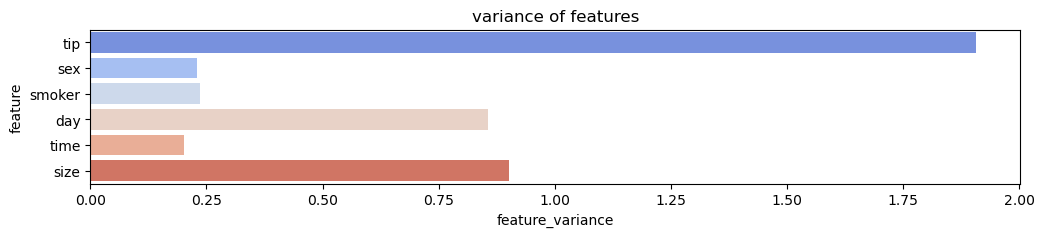

In [373]:
result_var_th(x,0.1)

In [374]:
select_k_best(x, y, f_regression, SelectKBest,5)

(Index(['tip', 'sex', 'smoker', 'time', 'size'], dtype='object'),
 array([6.69247065e-34, 2.36116668e-02, 1.82010329e-01, 4.10462141e-03,
        4.39351014e-25]),
 array([6.69247065e-34, 2.36116668e-02, 1.82010329e-01, 4.98345205e-01,
        4.10462141e-03, 4.39351014e-25]))

In [375]:
select_k_best(x, y, f_regression, SelectPercentile,90)

(Index(['tip', 'sex', 'smoker', 'time', 'size'], dtype='object'),
 array([6.69247065e-34, 2.36116668e-02, 1.82010329e-01, 4.10462141e-03,
        4.39351014e-25]),
 array([6.69247065e-34, 2.36116668e-02, 1.82010329e-01, 4.98345205e-01,
        4.10462141e-03, 4.39351014e-25]))

Feature_Selected is  Index(['tip', 'sex', 'smoker', 'time', 'size'], dtype='object')


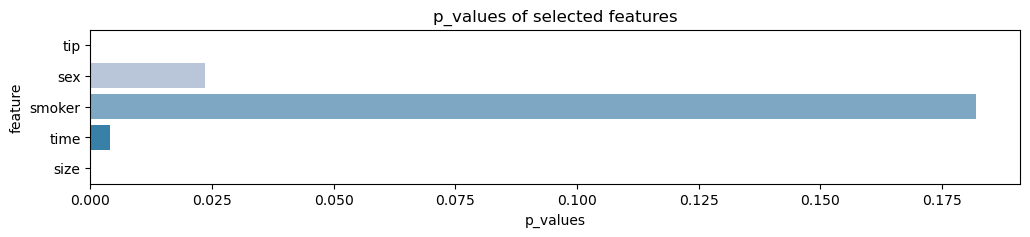

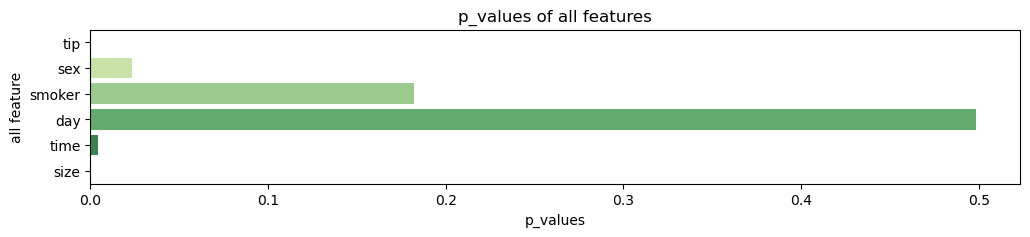

In [376]:
result_select_k(x, y, f_regression, SelectKBest,5)